In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
data_dir = "/content/drive/MyDrive/Classifying Types of Street Waste using Deep Learning."

In [7]:
import os

test_dir = "/content/drive/MyDrive/Classifying Types of Street Waste using Deep Learning./archive (5)/DATASET/TEST"
train_dir = "/content/drive/MyDrive/Classifying Types of Street Waste using Deep Learning./archive (5)/DATASET/TRAIN"
dataset = "/content/drive/MyDrive/Classifying Types of Street Waste using Deep Learning./archive (5)/DATASET/DATASET"



print(os.listdir(test_dir))
print(os.listdir(train_dir))
print(os.listdir(dataset))

['O', 'R']
['R', 'O']
['TRAIN', 'TEST']


In [8]:
import tensorflow as tf

IMG_SIZE = 224
BATCH_SIZE = 32

train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

Found 9999 files belonging to 2 classes.
Found 909 files belonging to 2 classes.


In [10]:
class_names = train_dataset.class_names
print(class_names)
class_names1=test_dataset.class_names
print(class_names1)

['O', 'R']
['O', 'R']


In [11]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

In [12]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50

IMG_SIZE = 224

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# base model freeze
base_model.trainable = False

model = tf.keras.Sequential([

    # Data augmentation
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),

    base_model,

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),

    # Binary classification
    tf.keras.layers.Dense(1, activation='sigmoid')
])

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [13]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

In [14]:
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=20
)

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 1694s 5s/step - accuracy: 0.9709 - auc: 0.0000e+00 - loss: 0.0828 - precision: 1.0000 - recall: 0.9709 - val_accuracy: 0.0000e+00 - val_auc: 0.0000e+00 - val_loss: 7.8885 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 49s 155ms/step - accuracy: 1.0000 - auc: 0.0000e+00 - loss: 0.0032 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 0.0000e+00 - val_auc: 0.0000e+00 - val_loss: 10.8511 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 49s 156ms/step - accuracy: 1.0000 - auc: 0.0000e+00 - loss: 0.0013 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 0.0000e+00 - val_auc: 0.0000e+00 - val_loss: 12.2344 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 82s 157ms/step - accuracy: 1.0000 - auc: 0.0000e+00 - loss: 6.3003e-04 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 0.0000e+00 - val_auc: 0.0000e+00 - val_l

In [15]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

In [16]:
history_fine = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=10
)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 49s 155ms/step - accuracy: 1.0000 - auc: 0.0000e+00 - loss: 8.7618e-06 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 0.0000e+00 - val_auc: 0.0000e+00 - val_loss: 21.0635 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 49s 155ms/step - accuracy: 1.0000 - auc: 0.0000e+00 - loss: 7.2697e-06 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 0.0000e+00 - val_auc: 0.0000e+00 - val_loss: 21.4390 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 48s 155ms/step - accuracy: 1.0000 - auc: 0.0000e+00 - loss: 5.5604e-06 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 0.0000e+00 - val_auc: 0.0000e+00 - val_loss: 21.7993 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 82s 155ms/step - accuracy: 1.0000 - auc: 0.0000e+00 - loss: 4.9465e-06 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 0.0000e+00 - val_auc: 0.00

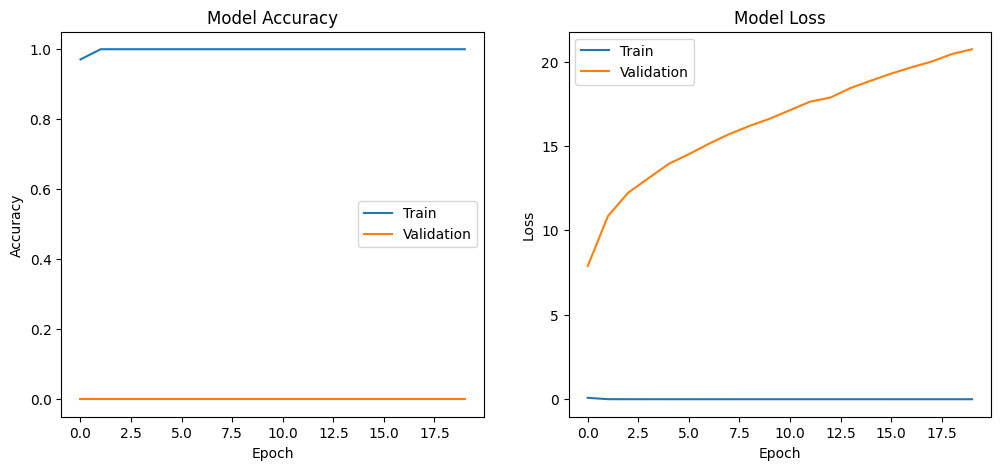

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])

plt.show()

In [19]:
y_true = []
y_pred = []

for images, labels in test_dataset:

    preds = model.predict(images)
    preds = (preds > 0.5).astype(int)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

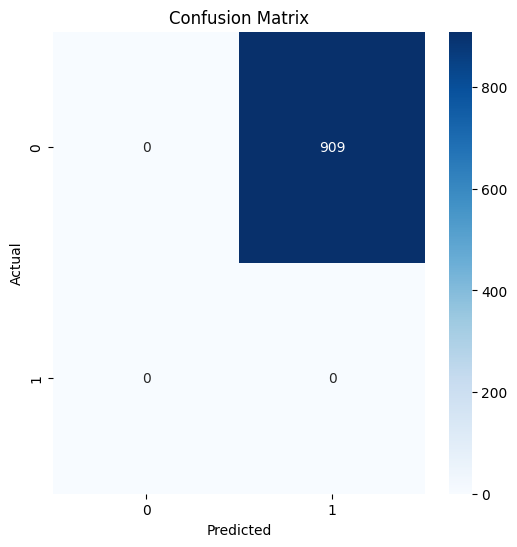

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [23]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00     909.0
           1       0.00      0.00      0.00       0.0

    accuracy                           0.00     909.0
   macro avg       0.00      0.00      0.00     909.0
weighted avg       0.00      0.00      0.00     909.0



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

In [24]:
model.save("waste_classification_resnet50.h5")

In [25]:
model = tf.keras.models.load_model("waste_classification_resnet50.h5")